# Exploratory Data Analysis — Zurich Datathon 2026

**Task**: Predict market direction at the halfway point of a synthetic trading session and size a position accordingly. Evaluated by Sharpe ratio.

**Data overview**:
- `bars_seen_train`: bars 0–49 (first half) for 1000 training sessions
- `bars_unseen_train`: bars 50–99 (second half) for the same 1000 sessions
- `headlines_seen_train` / `headlines_unseen_train`: fictional news headlines per bar

**Structure**: Each session has exactly 100 bars total, prices normalised to open at 1.0.

## 1. Imports & Data Loading

In [31]:
import sys
sys.executable  # confirm we're using .venv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
sns.set_palette("tab10")

DATA = "../data"
bars_seen     = pd.read_parquet(f"{DATA}/bars_seen_train.parquet")
bars_unseen   = pd.read_parquet(f"{DATA}/bars_unseen_train.parquet")
hl_seen       = pd.read_parquet(f"{DATA}/headlines_seen_train.parquet")
hl_unseen     = pd.read_parquet(f"{DATA}/headlines_unseen_train.parquet")

# Sort consistently
for df in [bars_seen, bars_unseen, hl_seen, hl_unseen]:
    df.sort_values(["session", "bar_ix"], inplace=True)
    df.reset_index(drop=True, inplace=True)

print("bars_seen   :", bars_seen.shape)
print("bars_unseen :", bars_unseen.shape)
print("hl_seen     :", hl_seen.shape)
print("hl_unseen   :", hl_unseen.shape)
bars_seen.head()

bars_seen   : (50000, 6)
bars_unseen : (50000, 6)
hl_seen     : (9740, 3)
hl_unseen   : (7631, 3)


,bar_ix,session,open,high,low,close
0,0,0,1.0000,1.0029,0.9986,0.9999
1,1,0,0.9997,1.0040,0.9991,1.0033
2,2,0,1.0034,1.0040,1.0015,1.0028
3,3,0,1.0023,1.0059,1.0021,1.0056
4,4,0,1.0057,1.0067,1.0043,1.0048


In [32]:
# ── Derived frames used throughout ──────────────────────────────────────────
all_bars = pd.concat([bars_seen, bars_unseen]).sort_values(["session", "bar_ix"]).reset_index(drop=True)

# Bar-to-bar returns within seen / unseen halves
bars_seen   = bars_seen.copy()
bars_unseen = bars_unseen.copy()
bars_seen["bar_return"]   = bars_seen.groupby("session")["close"].pct_change()
bars_unseen["bar_return"] = bars_unseen.groupby("session")["close"].pct_change()

# Halfway close (bar 49) and end close (bar 99) — the key target
halfway = bars_seen[bars_seen["bar_ix"] == 49][["session", "close"]].rename(columns={"close": "close_half"})
end     = bars_unseen[bars_unseen["bar_ix"] == 99][["session", "close"]].rename(columns={"close": "close_end"})
target  = halfway.merge(end, on="session")
target["return_2h"] = target["close_end"] / target["close_half"] - 1   # 2nd-half return
target["direction"] = np.sign(target["return_2h"])

# Session-level stats from seen half
session_stats = bars_seen.groupby("session").agg(
    first_open   = ("open", "first"),
    last_close   = ("close", "last"),
    vol_hl       = ("close", lambda x: x.std()),  # realised vol
    spread_mean  = ("close", lambda x: (bars_seen.loc[x.index, "high"] - bars_seen.loc[x.index, "low"]).mean()),
    bar_return_mean = ("bar_return", "mean"),
    bar_return_std  = ("bar_return", "std"),
).reset_index()
session_stats["first_half_return"] = session_stats["last_close"] / session_stats["first_open"] - 1
session_stats = session_stats.merge(target, on="session")

print("session_stats shape:", session_stats.shape)
session_stats.head(3)

session_stats shape: (1000, 12)


,session,first_open,last_close,vol_hl,spread_mean,bar_return_mean,bar_return_std,first_half_return,close_half,close_end,return_2h,direction
0,0,1.0,1.0316,0.009548,0.003924,0.000640,0.002578,0.0316,1.0316,1.0528,0.020551,1.0
1,1,1.0,1.0286,0.016093,0.004760,0.000559,0.003423,0.0286,1.0286,0.9774,-0.049776,-1.0
2,2,1.0,1.0208,0.007259,0.005298,0.000516,0.004027,0.0208,1.0208,1.0488,0.027429,1.0


## 2. Dataset Structure Overview

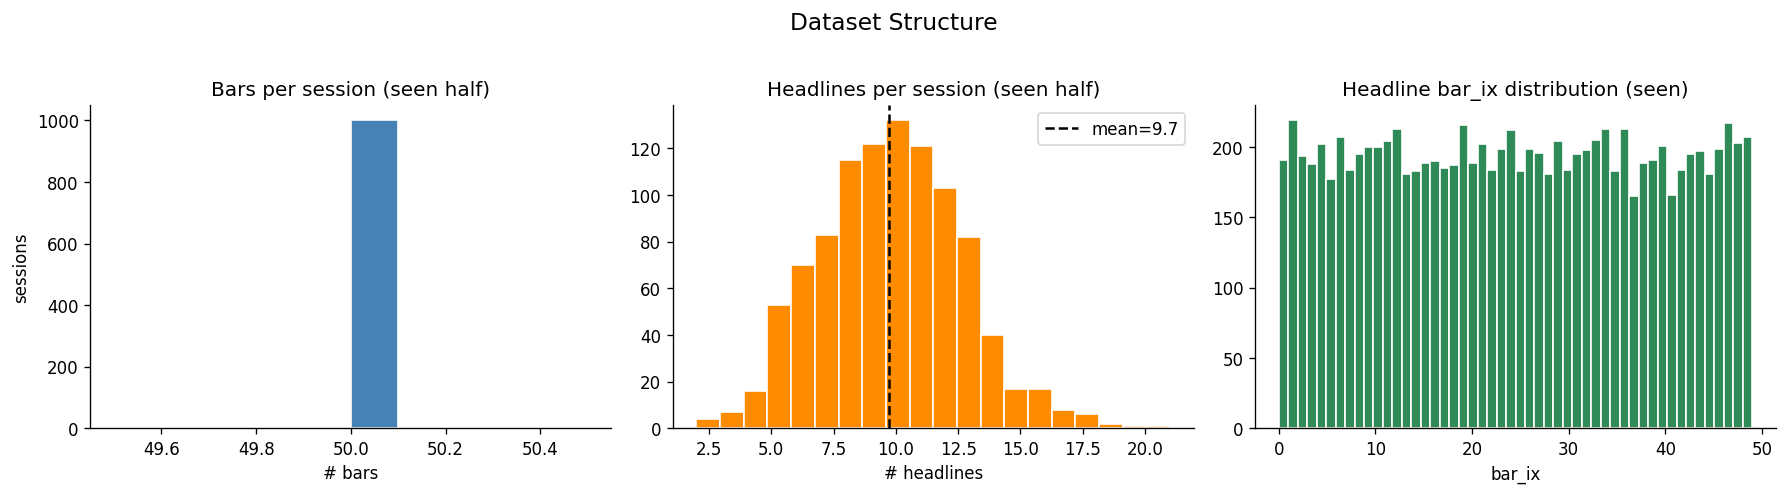

Sessions: 1000
Seen bars  per session: always 50 (bar_ix 0–49)
Unseen bars per session: always 50 (bar_ix 50–99)
Headlines seen  — total: 9740, per session avg: 9.7, std: 3.0


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) bars per session
bars_per_session = bars_seen.groupby("session")["bar_ix"].count()
axes[0].hist(bars_per_session, bins=10, color="steelblue", edgecolor="white")
axes[0].set_title("Bars per session (seen half)")
axes[0].set_xlabel("# bars"); axes[0].set_ylabel("sessions")

# (b) headlines per session
hl_per_session = hl_seen.groupby("session")["headline"].count()
axes[1].hist(hl_per_session, bins=20, color="darkorange", edgecolor="white")
axes[1].axvline(hl_per_session.mean(), color="k", linestyle="--", label=f"mean={hl_per_session.mean():.1f}")
axes[1].set_title("Headlines per session (seen half)")
axes[1].set_xlabel("# headlines"); axes[1].legend()

# (c) bar_ix distribution of headlines
axes[2].hist(hl_seen["bar_ix"], bins=50, color="seagreen", edgecolor="white")
axes[2].set_title("Headline bar_ix distribution (seen)")
axes[2].set_xlabel("bar_ix")

plt.suptitle("Dataset Structure", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Sessions: {bars_seen['session'].nunique()}")
print(f"Seen bars  per session: always 50 (bar_ix 0–49)")
print(f"Unseen bars per session: always 50 (bar_ix 50–99)")
print(f"Headlines seen  — total: {len(hl_seen)}, per session avg: {hl_per_session.mean():.1f}, std: {hl_per_session.std():.1f}")

## 3. Price Distribution & OHLC Statistics

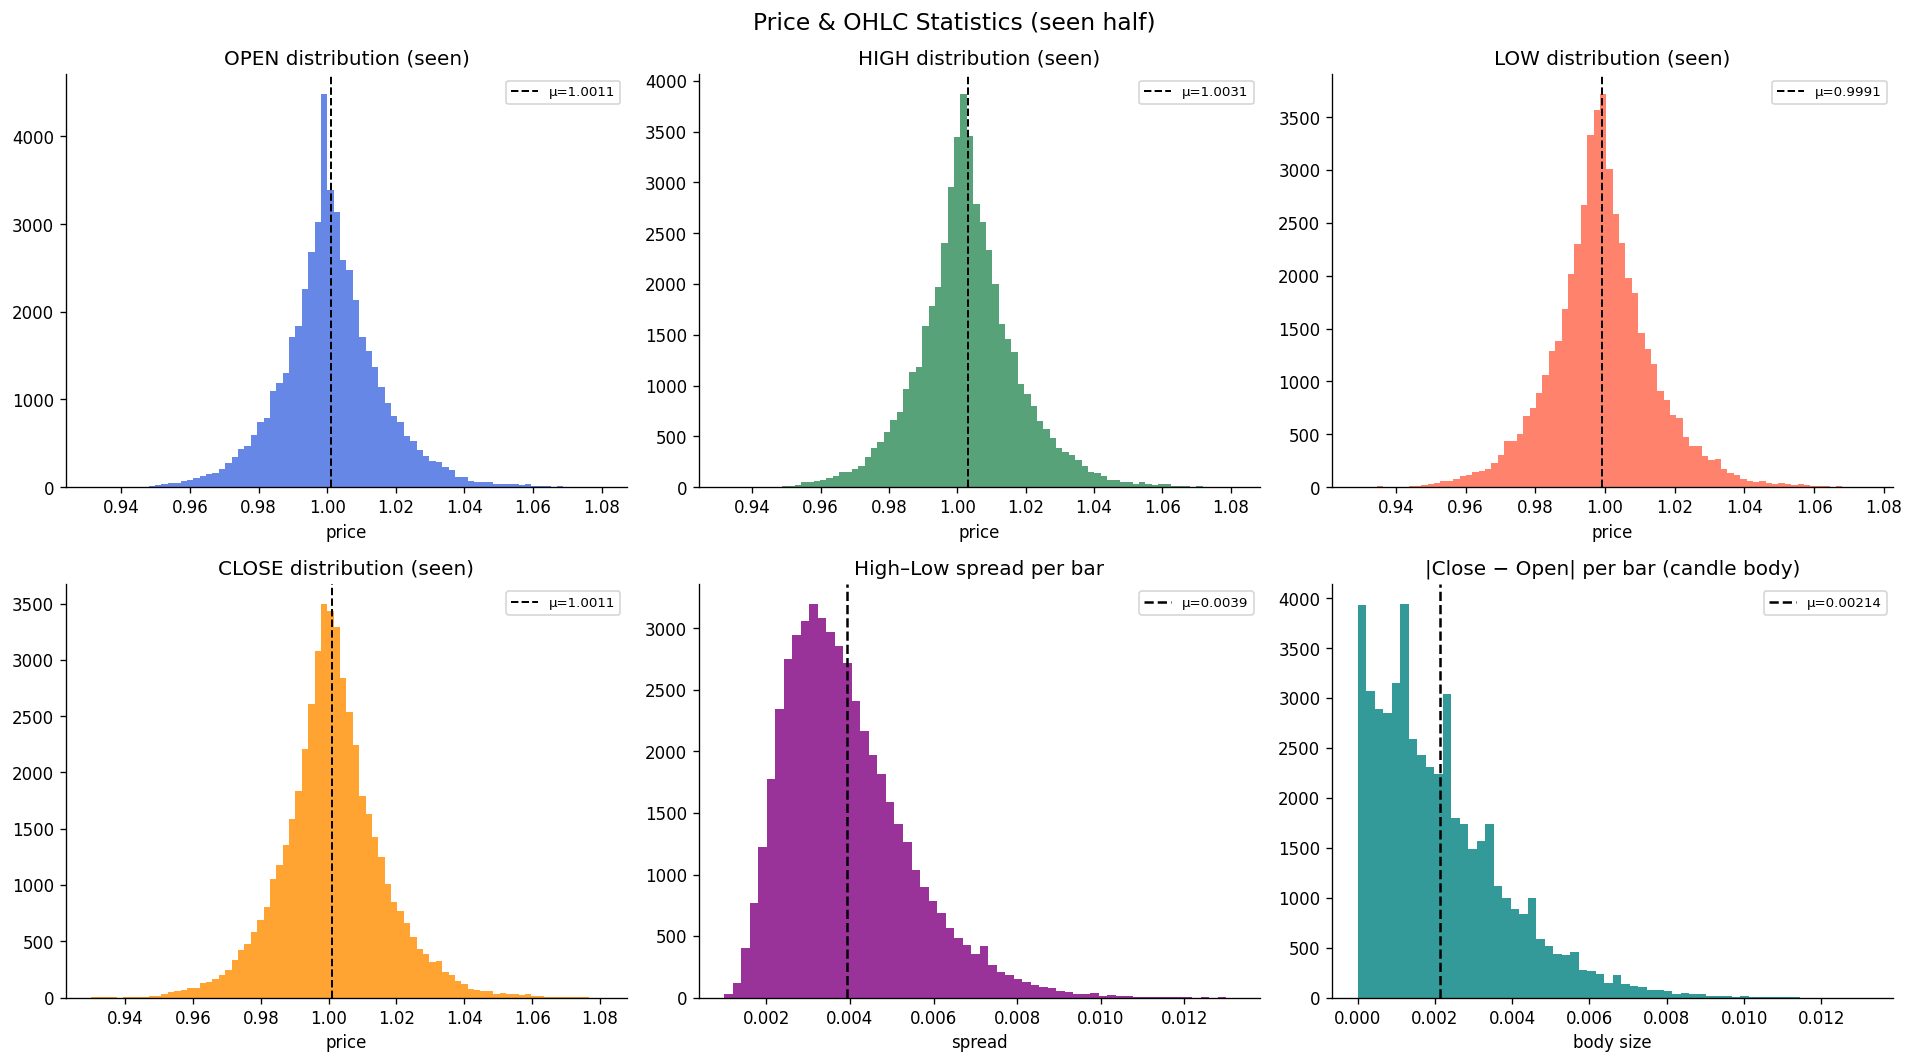

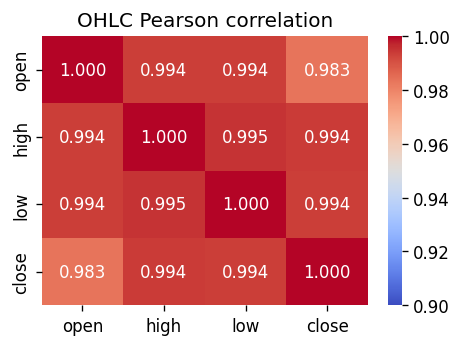

,open,high,low,close,high,hl_spread
count,50000.00000,50000.00000,50000.00000,50000.00000,50000.00000,50000.00000
mean,1.00109,1.00308,0.99914,1.00113,1.00308,0.00393
std,0.01470,0.01486,0.01479,0.01500,0.01486,0.00147
min,0.93120,0.93180,0.92900,0.93000,0.93180,0.00100
25%,0.99310,0.99490,0.99110,0.99280,0.99490,0.00290
50%,1.00040,1.00250,0.99880,1.00070,1.00250,0.00370
75%,1.00880,1.01090,1.00700,1.00910,1.01090,0.00470
max,1.08000,1.08120,1.07540,1.08050,1.08120,0.01320


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cols   = ["open", "high", "low", "close"]
colors = ["royalblue", "seagreen", "tomato", "darkorange"]
# Explicit positions — avoids the collision between the loop and the spread block
positions = [(0, 0), (0, 1), (0, 2), (1, 0)]

for col, c, pos in zip(cols, colors, positions):
    ax = axes[pos]
    ax.hist(bars_seen[col], bins=80, color=c, alpha=0.8, edgecolor="none")
    ax.axvline(bars_seen[col].mean(), color="black", linestyle="--", linewidth=1.2,
               label=f"μ={bars_seen[col].mean():.4f}")
    ax.set_title(f"{col.upper()} distribution (seen)")
    ax.set_xlabel("price"); ax.legend(fontsize=8)

# High-Low spread — now correctly at axes[1, 1]
spread = bars_seen["high"] - bars_seen["low"]
axes[1, 1].hist(spread, bins=60, color="purple", alpha=0.8, edgecolor="none")
axes[1, 1].axvline(spread.mean(), color="k", linestyle="--", label=f"μ={spread.mean():.4f}")
axes[1, 1].set_title("High–Low spread per bar")
axes[1, 1].set_xlabel("spread"); axes[1, 1].legend(fontsize=8)

# Candle body size — at axes[1, 2]
body = (bars_seen["close"] - bars_seen["open"]).abs()
axes[1, 2].hist(body, bins=60, color="teal", alpha=0.8, edgecolor="none")
axes[1, 2].axvline(body.mean(), color="k", linestyle="--", label=f"μ={body.mean():.5f}")
axes[1, 2].set_title("|Close − Open| per bar (candle body)")
axes[1, 2].set_xlabel("body size"); axes[1, 2].legend(fontsize=8)

plt.suptitle("Price & OHLC Statistics (seen half)", fontsize=14)
plt.tight_layout()
plt.show()

# OHLC correlation heatmap in its own compact figure
fig2, ax2 = plt.subplots(figsize=(4, 3))
sns.heatmap(bars_seen[cols].corr(), ax=ax2, annot=True, fmt=".3f",
            cmap="coolwarm", vmin=0.9, vmax=1)
ax2.set_title("OHLC Pearson correlation")
plt.tight_layout()
plt.show()

bars_seen[cols + ["high"]].assign(hl_spread=spread).describe().round(5)

## 4. Return Distributions

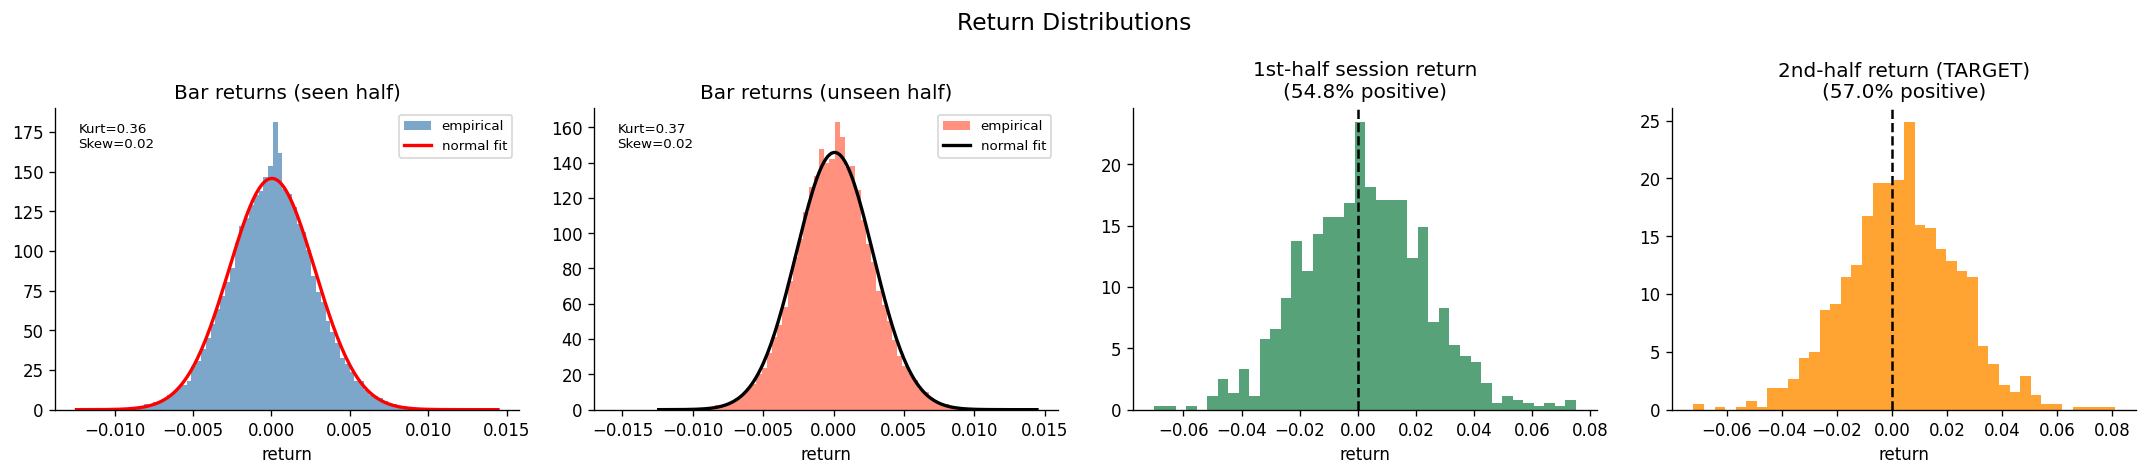

2nd-half return summary:
count    1000.00000
mean        0.00353
std         0.02043
min        -0.07202
25%        -0.00911
50%         0.00371
75%         0.01698
max         0.08088
Name: return_2h, dtype: float64


In [35]:
from scipy import stats

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1. Bar-to-bar returns (seen)
ret_seen = bars_seen["bar_return"].dropna()
axes[0].hist(ret_seen, bins=80, density=True, color="steelblue", alpha=0.7, label="empirical")
xmin, xmax = axes[0].get_xlim()
x = np.linspace(xmin, xmax, 200)
mu, std = ret_seen.mean(), ret_seen.std()
axes[0].plot(x, stats.norm.pdf(x, mu, std), "r-", lw=2, label="normal fit")
axes[0].set_title("Bar returns (seen half)")
axes[0].set_xlabel("return"); axes[0].legend(fontsize=8)
axes[0].text(0.05, 0.95, f"Kurt={ret_seen.kurt():.2f}\nSkew={ret_seen.skew():.2f}",
             transform=axes[0].transAxes, va="top", fontsize=8)

# 2. Bar returns (unseen)
ret_unseen = bars_unseen["bar_return"].dropna()
axes[1].hist(ret_unseen, bins=80, density=True, color="tomato", alpha=0.7, label="empirical")
mu2, std2 = ret_unseen.mean(), ret_unseen.std()
axes[1].plot(x, stats.norm.pdf(x, mu2, std2), "k-", lw=2, label="normal fit")
axes[1].set_title("Bar returns (unseen half)")
axes[1].set_xlabel("return"); axes[1].legend(fontsize=8)
axes[1].text(0.05, 0.95, f"Kurt={ret_unseen.kurt():.2f}\nSkew={ret_unseen.skew():.2f}",
             transform=axes[1].transAxes, va="top", fontsize=8)

# 3. Full-first-half session return (open bar0 → close bar49)
axes[2].hist(session_stats["first_half_return"], bins=40, color="seagreen", alpha=0.8, density=True)
axes[2].axvline(0, color="k", linestyle="--")
pct_pos = (session_stats["first_half_return"] > 0).mean()
axes[2].set_title(f"1st-half session return\n({pct_pos*100:.1f}% positive)")
axes[2].set_xlabel("return")

# 4. 2nd-half return (the TARGET)
axes[3].hist(session_stats["return_2h"], bins=40, color="darkorange", alpha=0.8, density=True)
axes[3].axvline(0, color="k", linestyle="--")
pct_pos2 = (session_stats["return_2h"] > 0).mean()
axes[3].set_title(f"2nd-half return (TARGET)\n({pct_pos2*100:.1f}% positive)")
axes[3].set_xlabel("return")

plt.suptitle("Return Distributions", fontsize=14)
plt.tight_layout()
plt.show()

print("2nd-half return summary:")
print(session_stats["return_2h"].describe().round(5))

## 5. Volatility & Spread Analysis

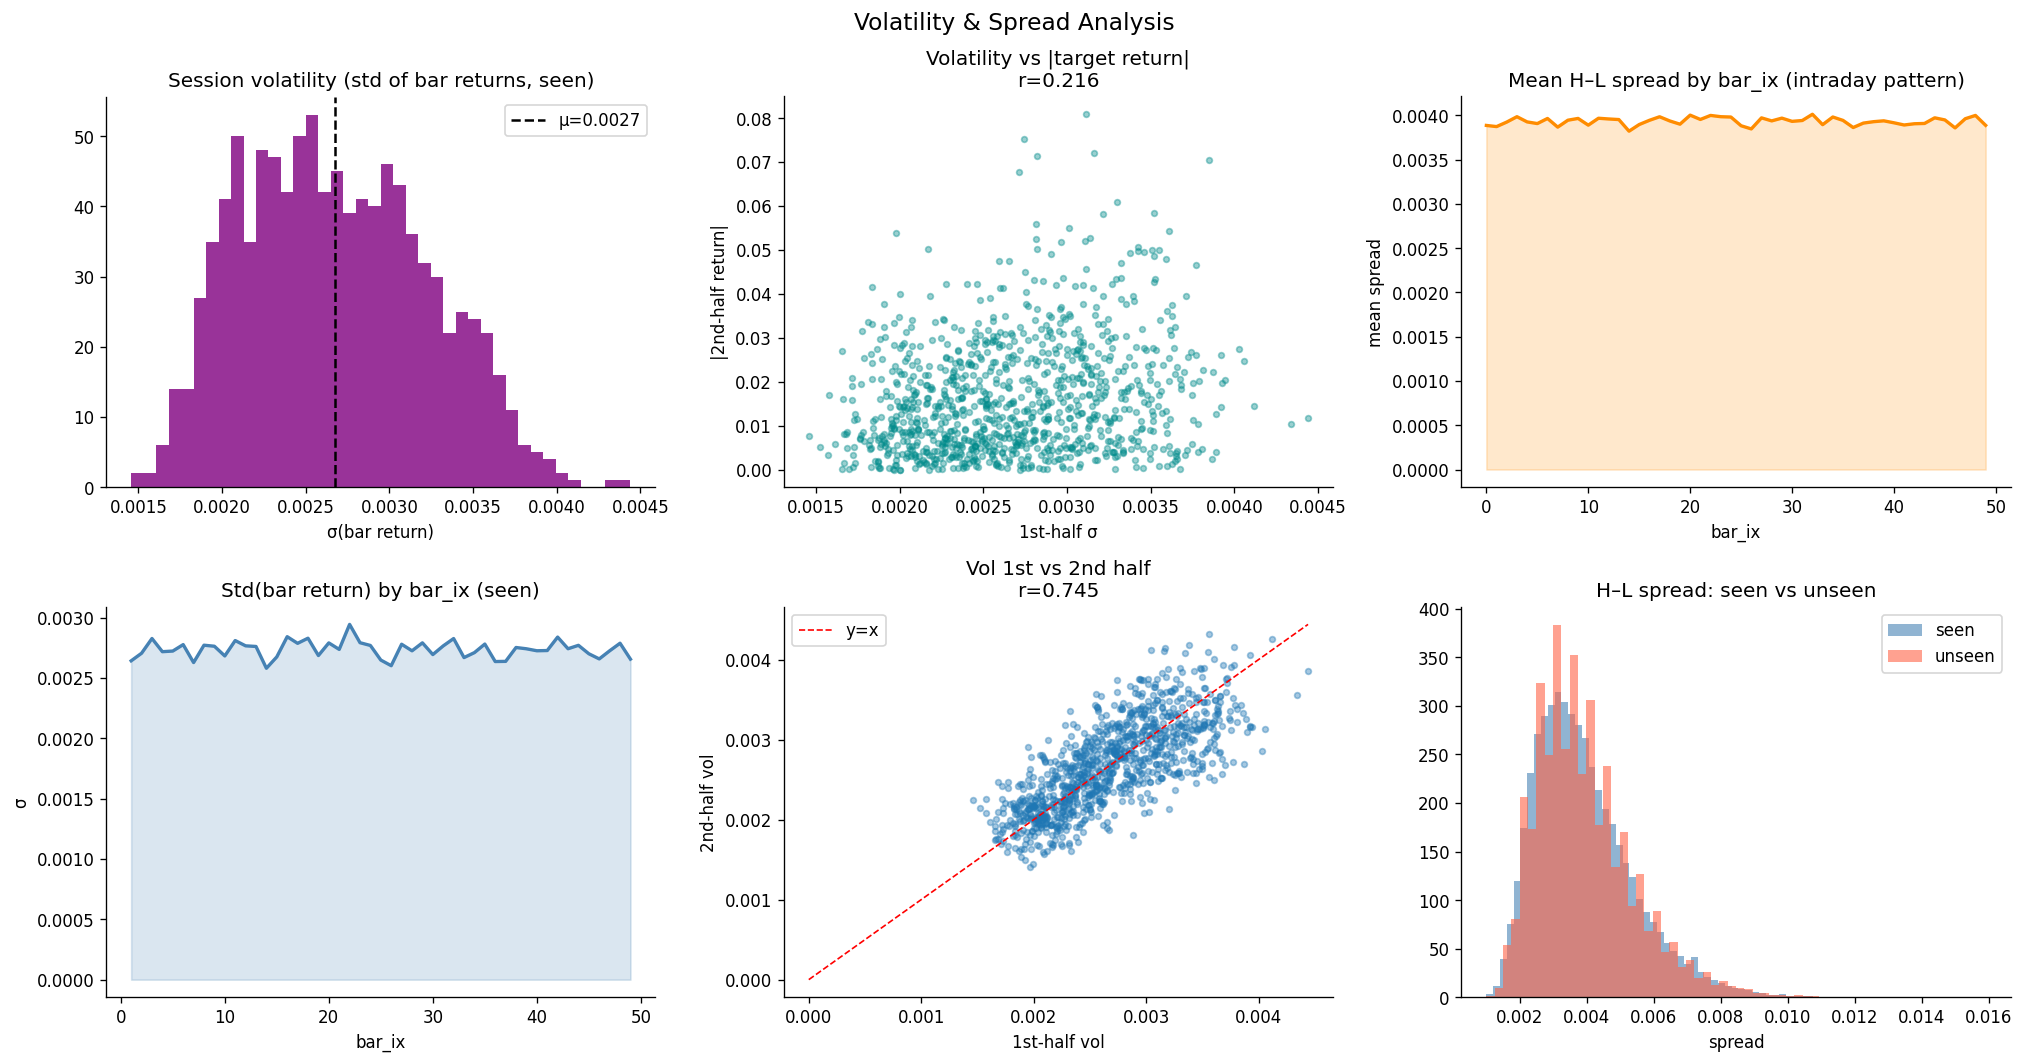

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# 1. Session volatility distribution
axes[0, 0].hist(session_stats["bar_return_std"], bins=40, color="purple", alpha=0.8)
axes[0, 0].axvline(session_stats["bar_return_std"].mean(), color="k", linestyle="--",
                    label=f"μ={session_stats['bar_return_std'].mean():.4f}")
axes[0, 0].set_title("Session volatility (std of bar returns, seen)")
axes[0, 0].set_xlabel("σ(bar return)"); axes[0, 0].legend()

# 2. Volatility vs 2nd-half return absolute
axes[0, 1].scatter(session_stats["bar_return_std"], session_stats["return_2h"].abs(),
                   alpha=0.4, s=12, color="darkcyan")
axes[0, 1].set_xlabel("1st-half σ"); axes[0, 1].set_ylabel("|2nd-half return|")
r = session_stats[["bar_return_std", "return_2h"]].apply(lambda x: x.abs() if x.name == "return_2h" else x).corr().iloc[0, 1]
axes[0, 1].set_title(f"Volatility vs |target return|\nr={session_stats['bar_return_std'].corr(session_stats['return_2h'].abs()):.3f}")

# 3. Mean H-L spread per bar_ix (intraday shape)
spread_by_bar = bars_seen.groupby("bar_ix").apply(lambda g: (g["high"] - g["low"]).mean())
axes[0, 2].plot(spread_by_bar.index, spread_by_bar.values, color="darkorange", linewidth=2)
axes[0, 2].fill_between(spread_by_bar.index, spread_by_bar.values, alpha=0.2, color="darkorange")
axes[0, 2].set_title("Mean H–L spread by bar_ix (intraday pattern)")
axes[0, 2].set_xlabel("bar_ix"); axes[0, 2].set_ylabel("mean spread")

# 4. Rolling volatility across bar_ix (seen half)
vol_by_bar = bars_seen.groupby("bar_ix")["bar_return"].std()
axes[1, 0].plot(vol_by_bar.index, vol_by_bar.values, color="steelblue", linewidth=2)
axes[1, 0].fill_between(vol_by_bar.index, vol_by_bar.values, alpha=0.2, color="steelblue")
axes[1, 0].set_title("Std(bar return) by bar_ix (seen)")
axes[1, 0].set_xlabel("bar_ix"); axes[1, 0].set_ylabel("σ")

# 5. Volatility comparison: 1st vs 2nd half
vol1 = session_stats["bar_return_std"]
vol2 = bars_unseen.groupby("session")["bar_return"].std()
vol_cmp = pd.DataFrame({"1st half": vol1.values, "2nd half": vol2.values})
axes[1, 1].scatter(vol_cmp["1st half"], vol_cmp["2nd half"], alpha=0.4, s=12)
lim = max(vol_cmp.max().max(), 0)
axes[1, 1].plot([0, lim], [0, lim], "r--", lw=1, label="y=x")
axes[1, 1].set_xlabel("1st-half vol"); axes[1, 1].set_ylabel("2nd-half vol")
axes[1, 1].set_title(f"Vol 1st vs 2nd half\nr={vol_cmp.corr().iloc[0,1]:.3f}")
axes[1, 1].legend()

# 6. H-L spread histogram: seen vs unseen
s_seen   = bars_seen["high"] - bars_seen["low"]
s_unseen = bars_unseen["high"] - bars_unseen["low"]
axes[1, 2].hist(s_seen,   bins=60, alpha=0.6, density=True, color="steelblue", label="seen")
axes[1, 2].hist(s_unseen, bins=60, alpha=0.6, density=True, color="tomato",    label="unseen")
axes[1, 2].set_title("H–L spread: seen vs unseen")
axes[1, 2].set_xlabel("spread"); axes[1, 2].legend()

plt.suptitle("Volatility & Spread Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Momentum & Mean-Reversion: Is the 1st Half Predictive?

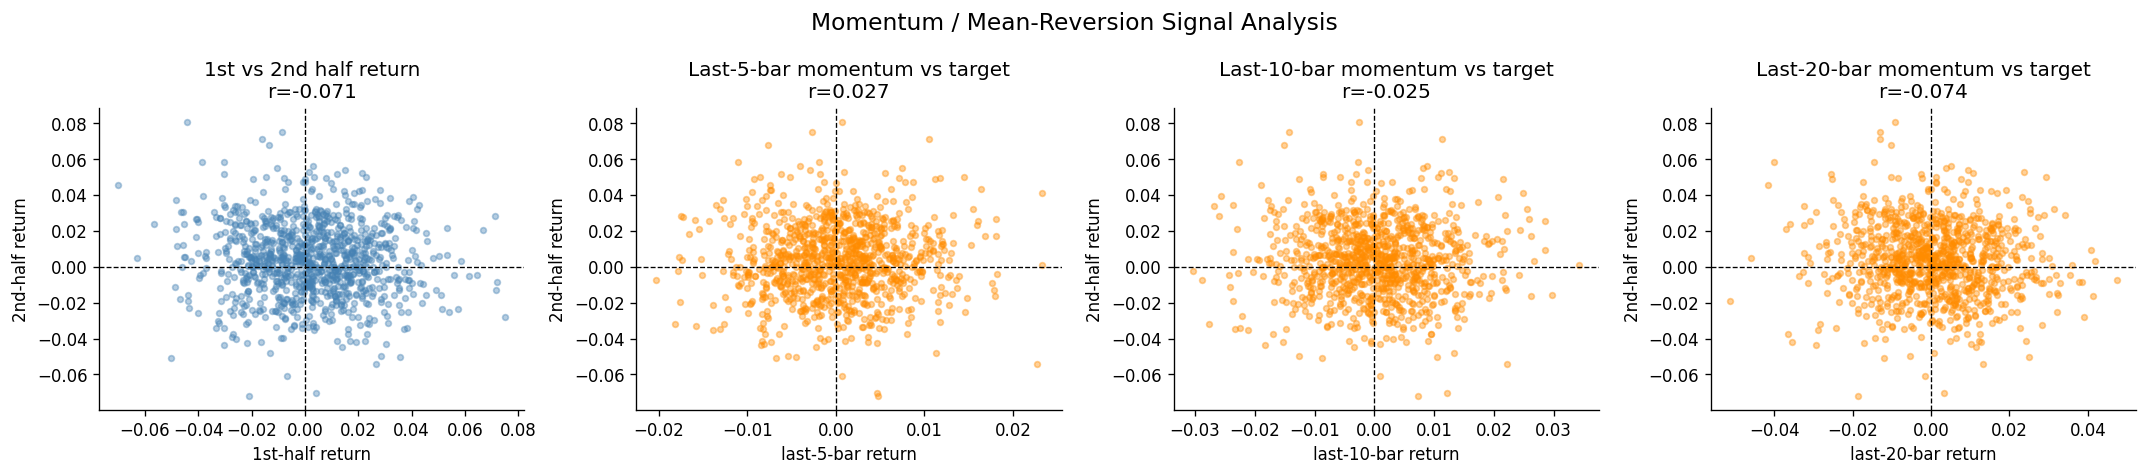

Direction contingency (1st-half row vs 2nd-half col):
direction  down  flat   up   All
dir_1h                          
down        173     2  274   449
flat          1     0    2     3
up          251     3  294   548
All         425     5  570  1000


In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 1. 1st-half return vs 2nd-half return (momentum vs mean-reversion)
axes[0].scatter(session_stats["first_half_return"], session_stats["return_2h"],
                alpha=0.4, s=12, color="steelblue")
axes[0].axhline(0, color="k", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="k", linewidth=0.8, linestyle="--")
r_mom = session_stats["first_half_return"].corr(session_stats["return_2h"])
axes[0].set_title(f"1st vs 2nd half return\nr={r_mom:.3f}")
axes[0].set_xlabel("1st-half return"); axes[0].set_ylabel("2nd-half return")

# 2. Last-N bars momentum signal
for n, ax in zip([5, 10, 20], axes[1:]):
    # Return over last n bars of seen half
    close_at_half  = bars_seen[bars_seen["bar_ix"] == 49][["session", "close"]].rename(columns={"close": "c_end"})
    close_at_start = bars_seen[bars_seen["bar_ix"] == (49 - n)][["session", "close"]].rename(columns={"close": "c_start"})
    mom = close_at_start.merge(close_at_half, on="session")
    mom["mom"] = mom["c_end"] / mom["c_start"] - 1
    mom = mom.merge(target[["session", "return_2h"]], on="session")
    r = mom["mom"].corr(mom["return_2h"])
    ax.scatter(mom["mom"], mom["return_2h"], alpha=0.4, s=12, color="darkorange")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
    ax.set_title(f"Last-{n}-bar momentum vs target\nr={r:.3f}")
    ax.set_xlabel(f"last-{n}-bar return"); ax.set_ylabel("2nd-half return")

plt.suptitle("Momentum / Mean-Reversion Signal Analysis", fontsize=14)
plt.tight_layout()
plt.show()

# Contingency table: 1st-half direction vs 2nd-half direction
session_stats["dir_1h"] = np.sign(session_stats["first_half_return"])
ct = pd.crosstab(session_stats["dir_1h"].map({-1:"down",-0.0:"flat",0:"flat",1:"up"}),
                  session_stats["direction"].map({-1:"down",-0.0:"flat",0:"flat",1:"up"}),
                  margins=True)
print("Direction contingency (1st-half row vs 2nd-half col):")
print(ct)

## 7. Autocorrelation & Serial Dependence

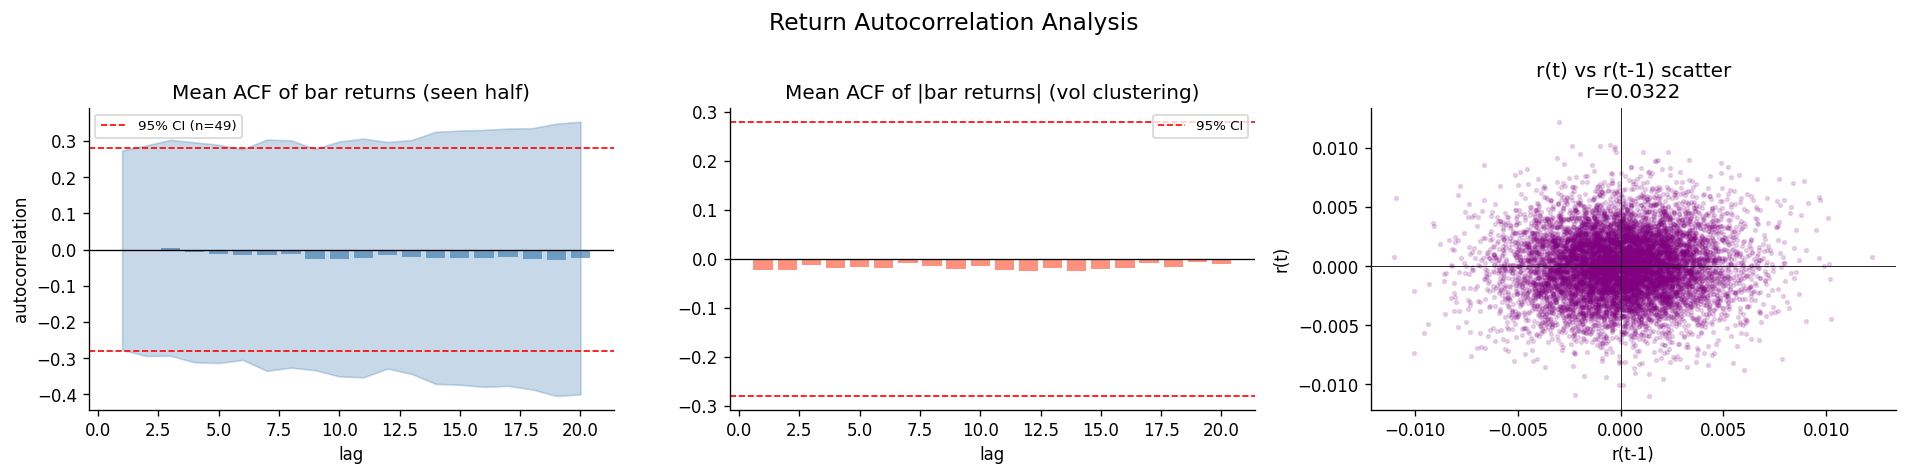

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Compute per-session autocorrelation and average
max_lag = 20
acf_matrix_seen = np.zeros((1000, max_lag))

for i, (sess, grp) in enumerate(bars_seen.groupby("session")):
    r = grp["bar_return"].dropna().values
    for lag in range(1, max_lag + 1):
        if len(r) > lag:
            acf_matrix_seen[i, lag - 1] = np.corrcoef(r[:-lag], r[lag:])[0, 1]

mean_acf = acf_matrix_seen.mean(axis=0)
std_acf  = acf_matrix_seen.std(axis=0)
lags = np.arange(1, max_lag + 1)

# 1. Mean ACF with ±2σ band
axes[0].bar(lags, mean_acf, color="steelblue", alpha=0.7)
axes[0].fill_between(lags, mean_acf - 2*std_acf, mean_acf + 2*std_acf, alpha=0.3, color="steelblue")
axes[0].axhline(0, color="k", linewidth=0.8)
axes[0].axhline( 1.96/np.sqrt(49), color="r", linestyle="--", linewidth=1, label="95% CI (n=49)")
axes[0].axhline(-1.96/np.sqrt(49), color="r", linestyle="--", linewidth=1)
axes[0].set_title("Mean ACF of bar returns (seen half)")
axes[0].set_xlabel("lag"); axes[0].set_ylabel("autocorrelation"); axes[0].legend(fontsize=8)

# 2. ACF of |returns| (volatility clustering)
acf_abs_matrix = np.zeros((1000, max_lag))
for i, (sess, grp) in enumerate(bars_seen.groupby("session")):
    r = grp["bar_return"].dropna().abs().values
    for lag in range(1, max_lag + 1):
        if len(r) > lag:
            acf_abs_matrix[i, lag - 1] = np.corrcoef(r[:-lag], r[lag:])[0, 1]

mean_acf_abs = acf_abs_matrix.mean(axis=0)
axes[1].bar(lags, mean_acf_abs, color="tomato", alpha=0.7)
axes[1].axhline(0, color="k", linewidth=0.8)
axes[1].axhline( 1.96/np.sqrt(49), color="r", linestyle="--", linewidth=1, label="95% CI")
axes[1].axhline(-1.96/np.sqrt(49), color="r", linestyle="--", linewidth=1)
axes[1].set_title("Mean ACF of |bar returns| (vol clustering)")
axes[1].set_xlabel("lag"); axes[1].legend(fontsize=8)

# 3. Lag-1 return scatter coloured by session
sample_sessions = bars_seen["session"].unique()[:200]
ret_lag1 = bars_seen[bars_seen["session"].isin(sample_sessions)].dropna(subset=["bar_return"])
lag1 = ret_lag1.groupby("session")["bar_return"].apply(lambda x: pd.Series({"r_t": x.values[1:], "r_t1": x.values[:-1]}))
r_t  = np.concatenate(ret_lag1.groupby("session")["bar_return"].apply(lambda x: x.values[1:]).values)
r_t1 = np.concatenate(ret_lag1.groupby("session")["bar_return"].apply(lambda x: x.values[:-1]).values)
axes[2].scatter(r_t1, r_t, alpha=0.15, s=5, color="purple")
axes[2].axhline(0, color="k", linewidth=0.5); axes[2].axvline(0, color="k", linewidth=0.5)
r_lag1 = np.corrcoef(r_t1, r_t)[0, 1]
axes[2].set_title(f"r(t) vs r(t-1) scatter\nr={r_lag1:.4f}")
axes[2].set_xlabel("r(t-1)"); axes[2].set_ylabel("r(t)")

plt.suptitle("Return Autocorrelation Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Session Price Path Visualisation

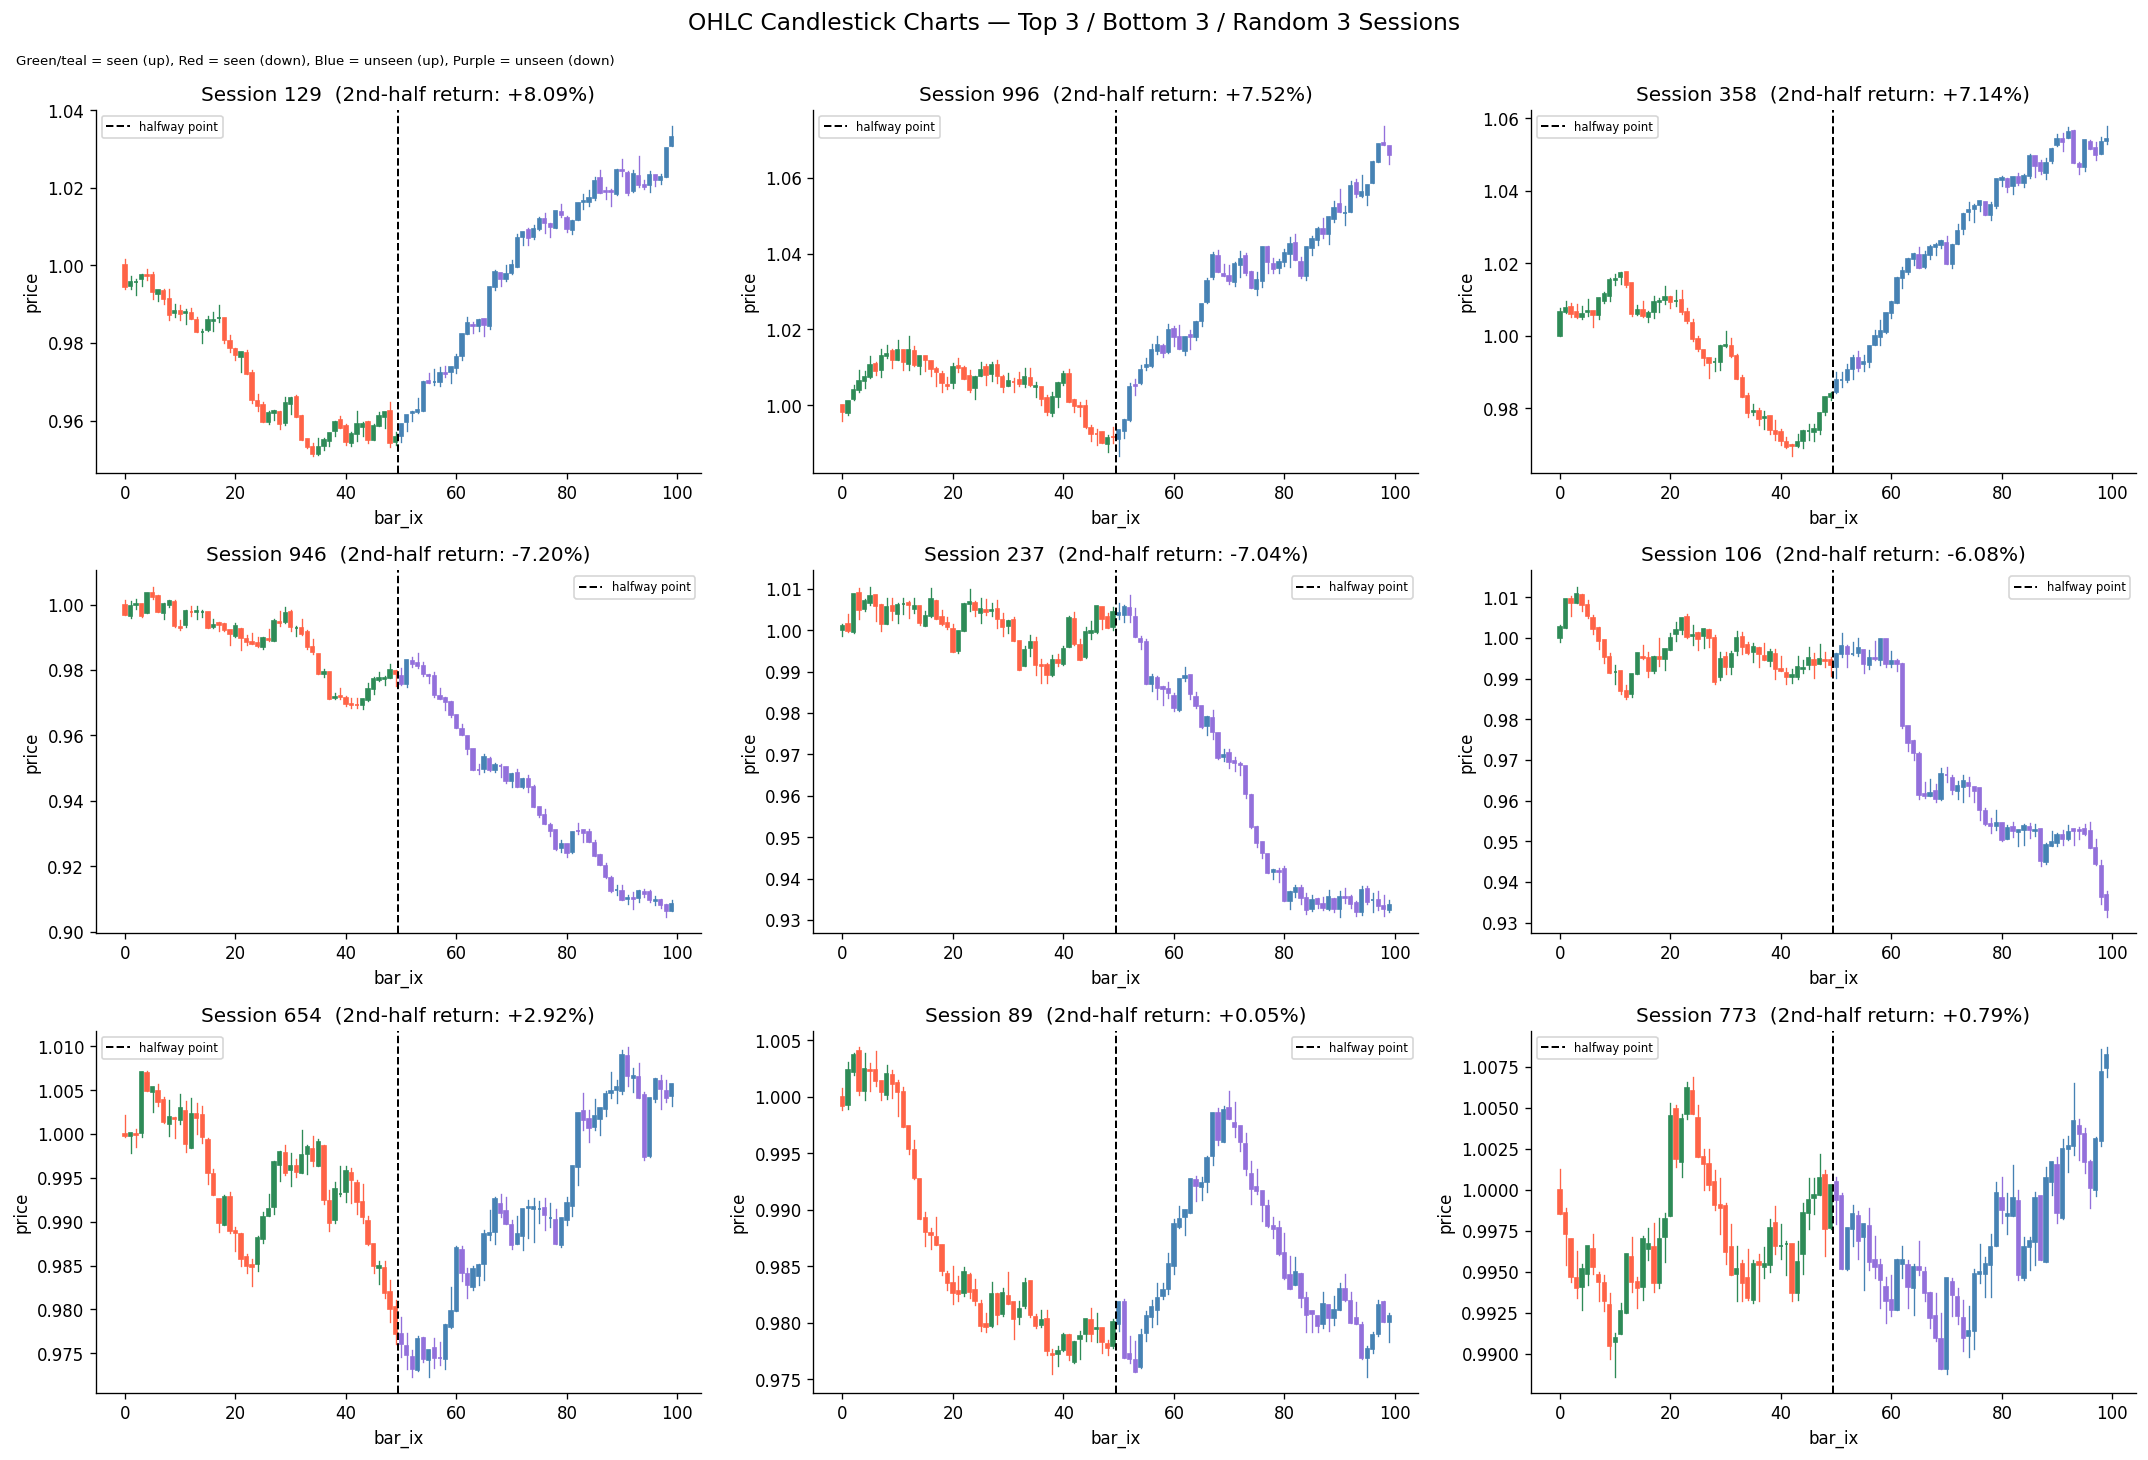

In [39]:
def plot_ohlc_session(ax, session_id, bars_seen, bars_unseen, title=None):
    seen   = bars_seen[bars_seen["session"] == session_id].sort_values("bar_ix")
    unseen = bars_unseen[bars_unseen["session"] == session_id].sort_values("bar_ix")

    for _, row in seen.iterrows():
        color = "seagreen" if row["close"] >= row["open"] else "tomato"
        ax.plot([row["bar_ix"], row["bar_ix"]], [row["low"], row["high"]], color=color, lw=0.8)
        ax.add_patch(plt.Rectangle((row["bar_ix"] - 0.3, min(row["open"], row["close"])),
                                    0.6, abs(row["close"] - row["open"]), color=color))

    for _, row in unseen.iterrows():
        color = "steelblue" if row["close"] >= row["open"] else "mediumpurple"
        ax.plot([row["bar_ix"], row["bar_ix"]], [row["low"], row["high"]], color=color, lw=0.8)
        ax.add_patch(plt.Rectangle((row["bar_ix"] - 0.3, min(row["open"], row["close"])),
                                    0.6, abs(row["close"] - row["open"]), color=color))

    ax.axvline(49.5, color="k", linestyle="--", lw=1.2, label="halfway point")
    r2h = target.loc[target["session"] == session_id, "return_2h"].values[0]
    ax.set_title(title or f"Session {session_id}  (2nd-half return: {r2h:+.2%})")
    ax.set_xlabel("bar_ix"); ax.set_ylabel("price")
    ax.legend(fontsize=7)

# Pick a diverse sample: highest / lowest 2nd-half return + random
top3    = session_stats.nlargest(3, "return_2h")["session"].values
bot3    = session_stats.nsmallest(3, "return_2h")["session"].values
rand3   = np.random.default_rng(42).choice(session_stats["session"].values, 3, replace=False)

sample_sessions = np.concatenate([top3, bot3, rand3])
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for ax, sid in zip(axes.flat, sample_sessions):
    plot_ohlc_session(ax, sid, bars_seen, bars_unseen)

fig.text(0.01, 0.98, "Green/teal = seen (up), Red = seen (down), Blue = unseen (up), Purple = unseen (down)",
         fontsize=8, va="top")
plt.suptitle("OHLC Candlestick Charts — Top 3 / Bottom 3 / Random 3 Sessions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

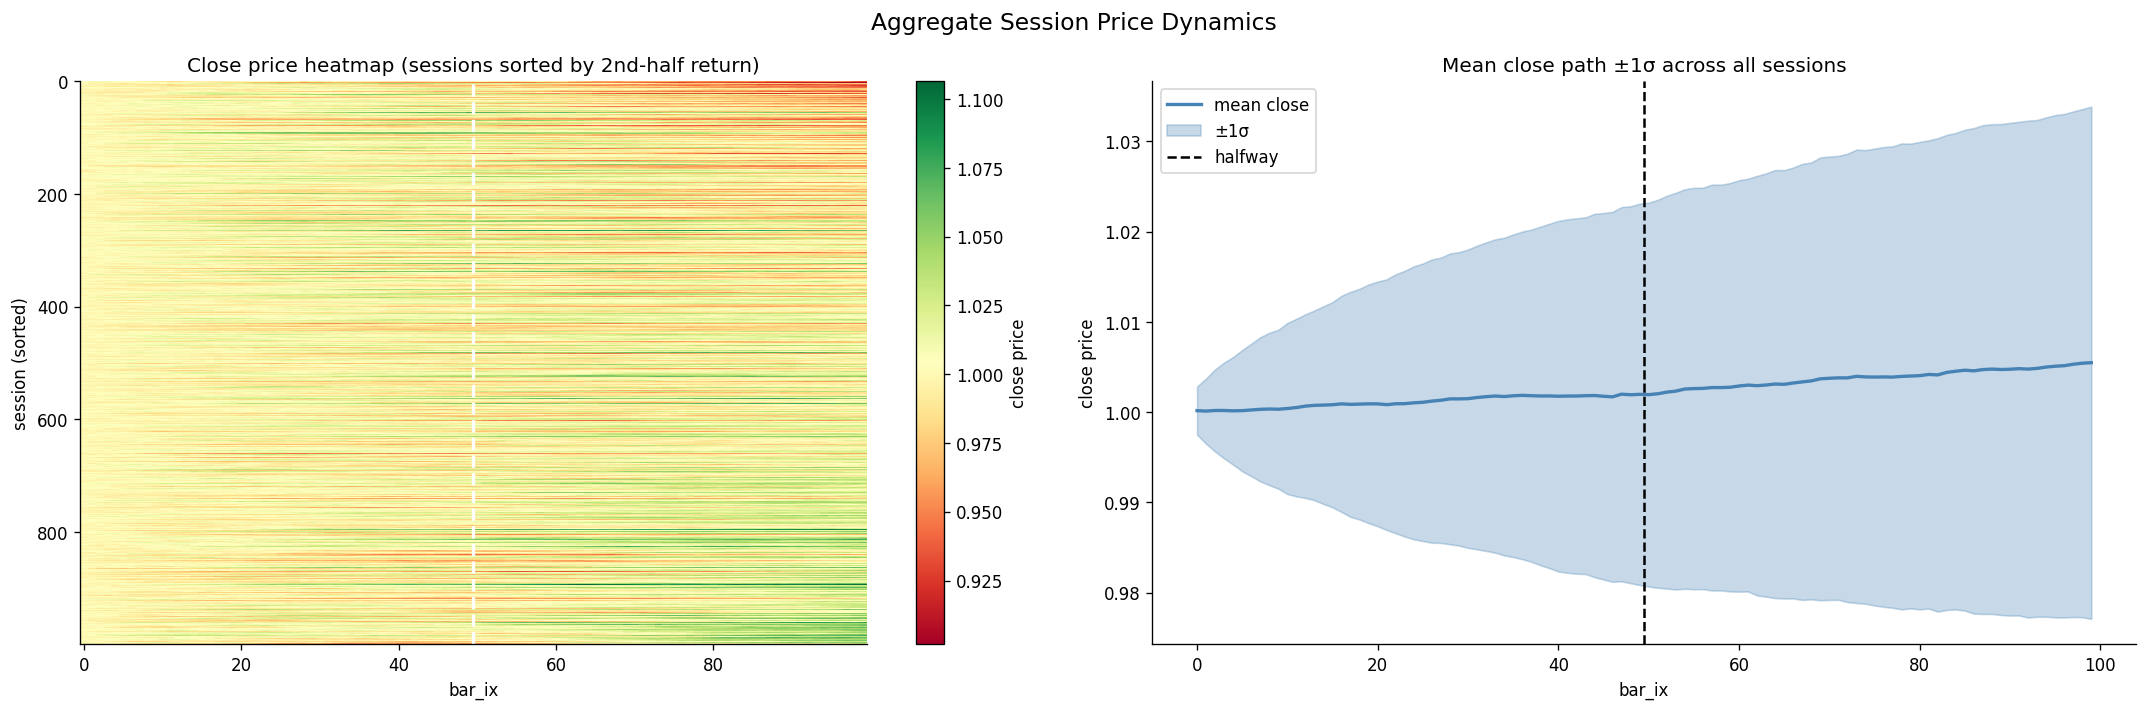

In [40]:
# ── All 1000 sessions: close price heatmap ───────────────────────────────────
close_matrix_seen   = bars_seen.pivot(index="session", columns="bar_ix", values="close")
close_matrix_unseen = bars_unseen.pivot(index="session", columns="bar_ix", values="close")
close_matrix = pd.concat([close_matrix_seen, close_matrix_unseen], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sort sessions by 2nd-half return for visual clarity
order = session_stats.sort_values("return_2h")["session"].values
cm_sorted = close_matrix.loc[order]

im = axes[0].imshow(cm_sorted.values, aspect="auto", cmap="RdYlGn", interpolation="none")
axes[0].axvline(49.5, color="white", lw=2, linestyle="--")
axes[0].set_title("Close price heatmap (sessions sorted by 2nd-half return)")
axes[0].set_xlabel("bar_ix"); axes[0].set_ylabel("session (sorted)")
plt.colorbar(im, ax=axes[0], label="close price")

# Mean close path across all sessions ± 1σ
mean_close = close_matrix.mean(axis=0)
std_close  = close_matrix.std(axis=0)
x = close_matrix.columns
axes[1].plot(x, mean_close, color="steelblue", lw=2, label="mean close")
axes[1].fill_between(x, mean_close - std_close, mean_close + std_close, alpha=0.3, color="steelblue", label="±1σ")
axes[1].axvline(49.5, color="k", linestyle="--", lw=1.5, label="halfway")
axes[1].set_title("Mean close path ±1σ across all sessions")
axes[1].set_xlabel("bar_ix"); axes[1].set_ylabel("close price"); axes[1].legend()

plt.suptitle("Aggregate Session Price Dynamics", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Session-Level Feature Correlations with Target

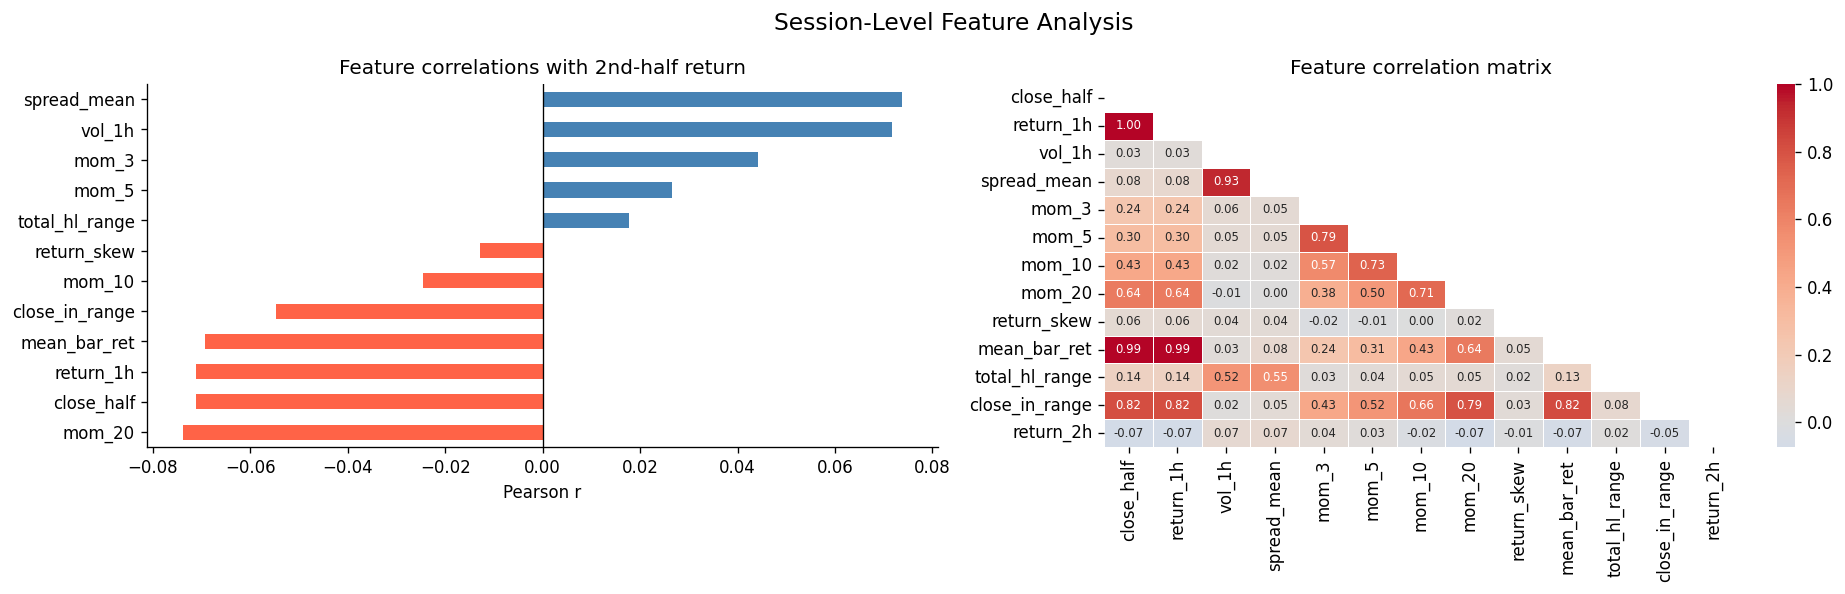


Top 5 positive predictors:
total_hl_range    0.017746
mom_5             0.026630
mom_3             0.044139
vol_1h            0.071635
spread_mean       0.073857

Top 5 negative predictors:
mom_20           -0.073911
close_half       -0.071157
return_1h        -0.071157
mean_bar_ret     -0.069385
close_in_range   -0.054788


In [41]:
# Build richer feature set from the seen half
feat = session_stats[["session", "return_2h"]].copy()

# Price-level features at halfway
feat["close_half"]  = session_stats["close_half"]
feat["return_1h"]   = session_stats["first_half_return"]
feat["vol_1h"]      = session_stats["bar_return_std"]
feat["spread_mean"] = session_stats["spread_mean"]

# Recent momentum windows
for n in [3, 5, 10, 20]:
    c_end   = bars_seen[bars_seen["bar_ix"] == 49][["session", "close"]].set_index("session")["close"]
    c_start = bars_seen[bars_seen["bar_ix"] == max(0, 49-n)][["session", "close"]].set_index("session")["close"]
    feat[f"mom_{n}"] = (c_end / c_start - 1).values

# Skewness of bar returns in seen half
skew = bars_seen.groupby("session")["bar_return"].skew()
feat["return_skew"] = skew.values

# Mean bar return
feat["mean_bar_ret"] = session_stats["bar_return_mean"].values

# H-L range of entire seen half (max high - min low)
feat["total_hl_range"] = (
    bars_seen.groupby("session")["high"].max() - bars_seen.groupby("session")["low"].min()
).values

# Close relative to seen-half range (position within range)
sess_max = bars_seen.groupby("session")["high"].max()
sess_min = bars_seen.groupby("session")["low"].min()
close_h  = bars_seen[bars_seen["bar_ix"] == 49].set_index("session")["close"]
feat["close_in_range"] = ((close_h - sess_min) / (sess_max - sess_min)).values

feature_cols = [c for c in feat.columns if c not in ["session", "return_2h"]]

# Pearson correlations with target
corr_with_target = feat[feature_cols + ["return_2h"]].corr()["return_2h"].drop("return_2h").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

corr_with_target.plot.barh(ax=axes[0], color=["tomato" if v < 0 else "steelblue" for v in corr_with_target])
axes[0].axvline(0, color="k", linewidth=0.8)
axes[0].set_title("Feature correlations with 2nd-half return")
axes[0].set_xlabel("Pearson r")

# Full correlation heatmap
corr_matrix = feat[feature_cols + ["return_2h"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], mask=mask, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.3)
axes[1].set_title("Feature correlation matrix")

plt.suptitle("Session-Level Feature Analysis", fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop 5 positive predictors:")
print(corr_with_target.tail(5).to_string())
print("\nTop 5 negative predictors:")
print(corr_with_target.head(5).to_string())

## 10. Target Return by Quantile Buckets

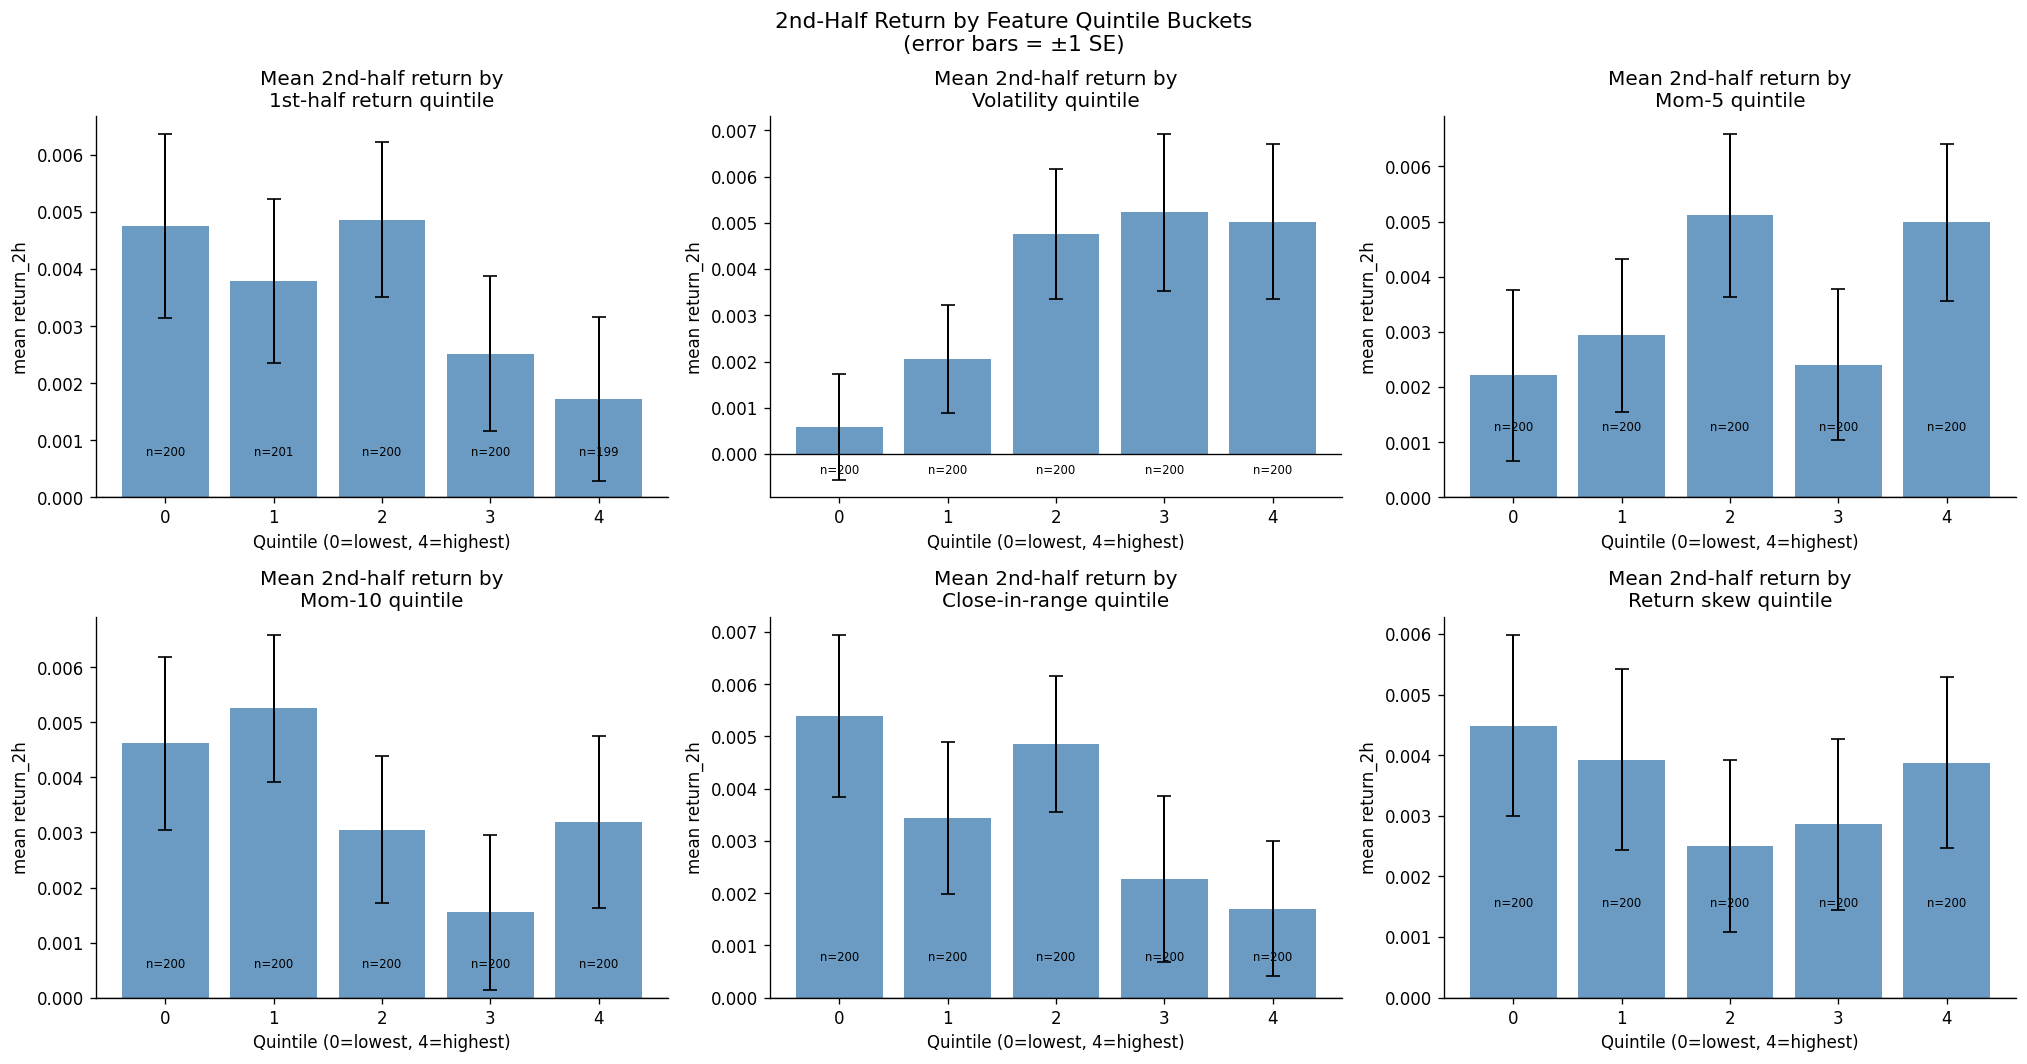

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

bucket_features = ["return_1h", "vol_1h", "mom_5", "mom_10", "close_in_range", "return_skew"]
bucket_labels   = ["1st-half return quintile", "Volatility quintile", "Mom-5 quintile",
                   "Mom-10 quintile", "Close-in-range quintile", "Return skew quintile"]

for ax, feature, label in zip(axes.flat, bucket_features, bucket_labels):
    feat["_bucket"] = pd.qcut(feat[feature], q=5, labels=False, duplicates="drop")
    grouped = feat.groupby("_bucket")["return_2h"].agg(["mean", "std", "count"])
    colors  = ["tomato" if v < 0 else "steelblue" for v in grouped["mean"]]
    ax.bar(grouped.index, grouped["mean"], color=colors, alpha=0.8)
    ax.errorbar(grouped.index, grouped["mean"], yerr=grouped["std"] / np.sqrt(grouped["count"]),
                fmt="none", color="k", capsize=4, lw=1.2)
    ax.axhline(0, color="k", linewidth=0.8)
    ax.set_title(f"Mean 2nd-half return by\n{label}")
    ax.set_xlabel("Quintile (0=lowest, 4=highest)"); ax.set_ylabel("mean return_2h")
    # Annotate with n
    for i, (idx, row) in enumerate(grouped.iterrows()):
        ax.text(idx, grouped["mean"].min() - 0.001, f"n={int(row['count'])}", ha="center", fontsize=7)

plt.suptitle("2nd-Half Return by Feature Quintile Buckets\n(error bars = ±1 SE)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Headlines Analysis

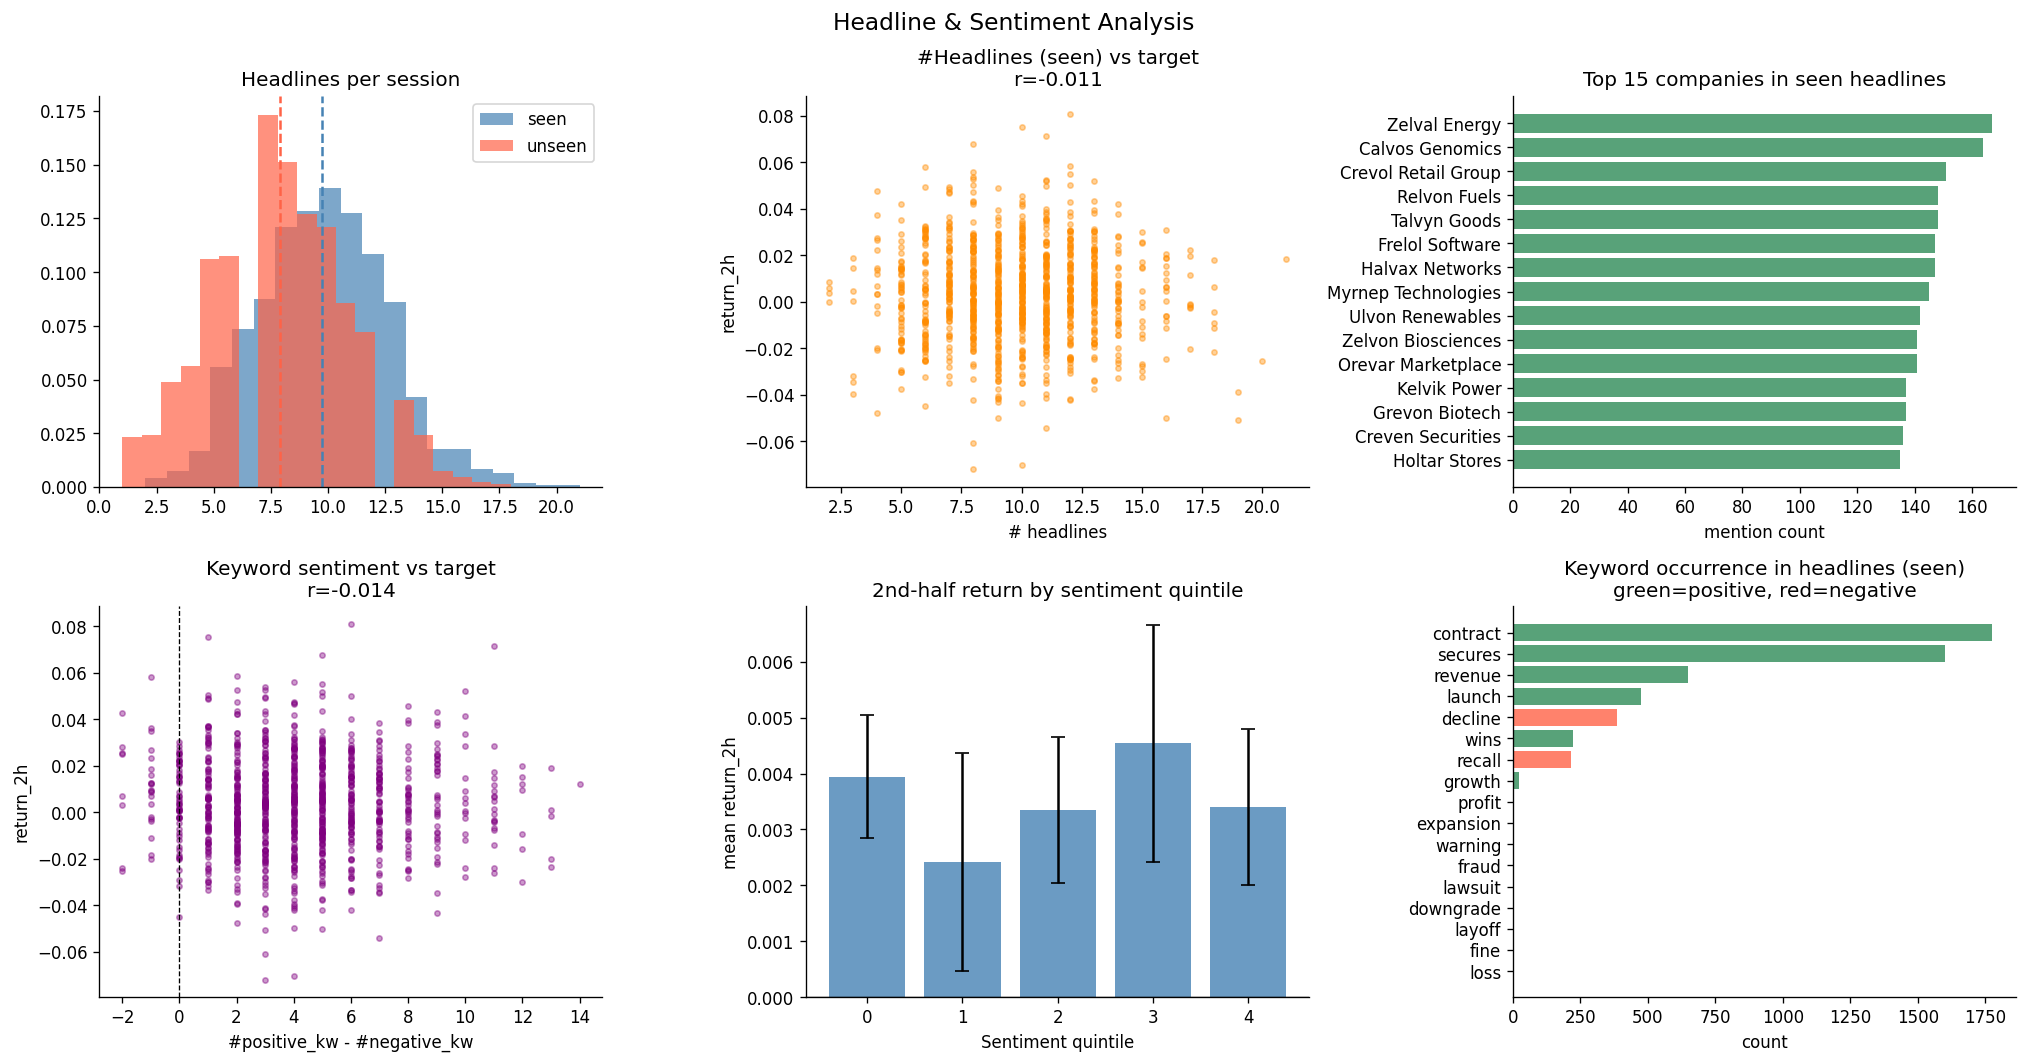

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# 1. Headlines per session distribution (seen vs unseen)
hl_per_seen   = hl_seen.groupby("session")["headline"].count()
hl_per_unseen = hl_unseen.groupby("session")["headline"].count()
axes[0, 0].hist(hl_per_seen,   bins=20, alpha=0.7, color="steelblue", label="seen", density=True)
axes[0, 0].hist(hl_per_unseen, bins=20, alpha=0.7, color="tomato",    label="unseen", density=True)
axes[0, 0].axvline(hl_per_seen.mean(), color="steelblue", linestyle="--")
axes[0, 0].axvline(hl_per_unseen.mean(), color="tomato", linestyle="--")
axes[0, 0].set_title("Headlines per session"); axes[0, 0].legend()

# 2. Headline count vs 2nd-half return
hl_cnt = hl_per_seen.reset_index().rename(columns={"headline": "n_headlines"})
hl_cnt = hl_cnt.merge(target[["session","return_2h"]], on="session")
axes[0, 1].scatter(hl_cnt["n_headlines"], hl_cnt["return_2h"], alpha=0.4, s=10, color="darkorange")
r = hl_cnt["n_headlines"].corr(hl_cnt["return_2h"])
axes[0, 1].set_title(f"#Headlines (seen) vs target\nr={r:.3f}")
axes[0, 1].set_xlabel("# headlines"); axes[0, 1].set_ylabel("return_2h")

# 3. Most frequent company mentions (seen)
company_pattern = re.compile(r'^([A-Z][a-zA-Z]+(?: [A-Z][a-zA-Z]+)*)')
companies_seen = []
for h in hl_seen["headline"]:
    m = company_pattern.match(h)
    if m:
        companies_seen.append(m.group(1))

cnt = Counter(companies_seen)
top_companies = pd.DataFrame(cnt.most_common(15), columns=["company", "count"])
axes[0, 2].barh(top_companies["company"][::-1], top_companies["count"][::-1], color="seagreen", alpha=0.8)
axes[0, 2].set_title("Top 15 companies in seen headlines")
axes[0, 2].set_xlabel("mention count")

# 4. Keyword frequency analysis
positive_kw = ["contract", "revenue", "growth", "profit", "expansion", "secures", "wins", "launch"]
negative_kw = ["loss", "decline", "lawsuit", "downgrade", "recall", "layoff", "fine", "fraud", "warning"]

def count_kw(headlines, keywords):
    total = sum(1 for h in headlines for kw in keywords if kw.lower() in h.lower())
    return total

pos_counts = []
neg_counts = []
for sess, grp in hl_seen.groupby("session"):
    pos_counts.append(sum(1 for h in grp["headline"] for kw in positive_kw if kw.lower() in h.lower()))
    neg_counts.append(sum(1 for h in grp["headline"] for kw in negative_kw if kw.lower() in h.lower()))

kw_df = pd.DataFrame({"session": hl_seen["session"].unique(), "pos_kw": pos_counts, "neg_kw": neg_counts})
kw_df["sentiment_proxy"] = kw_df["pos_kw"] - kw_df["neg_kw"]
kw_df = kw_df.merge(target[["session","return_2h"]], on="session")

axes[1, 0].scatter(kw_df["sentiment_proxy"], kw_df["return_2h"], alpha=0.4, s=10, color="purple")
r_sent = kw_df["sentiment_proxy"].corr(kw_df["return_2h"])
axes[1, 0].axvline(0, color="k", linewidth=0.8, linestyle="--")
axes[1, 0].set_title(f"Keyword sentiment vs target\nr={r_sent:.3f}")
axes[1, 0].set_xlabel("#positive_kw - #negative_kw"); axes[1, 0].set_ylabel("return_2h")

# 5. Sentiment by bucket
kw_df["_bucket"] = pd.qcut(kw_df["sentiment_proxy"], q=5, labels=False, duplicates="drop")
grouped = kw_df.groupby("_bucket")["return_2h"].agg(["mean", "std", "count"])
colors  = ["tomato" if v < 0 else "steelblue" for v in grouped["mean"]]
axes[1, 1].bar(grouped.index, grouped["mean"], color=colors, alpha=0.8)
axes[1, 1].errorbar(grouped.index, grouped["mean"], yerr=grouped["std"] / np.sqrt(grouped["count"]),
                    fmt="none", color="k", capsize=4)
axes[1, 1].axhline(0, color="k", linewidth=0.8)
axes[1, 1].set_title("2nd-half return by sentiment quintile")
axes[1, 1].set_xlabel("Sentiment quintile"); axes[1, 1].set_ylabel("mean return_2h")

# 6. Positive vs negative keyword occurrence
all_kw = positive_kw + negative_kw
kw_totals = {}
for kw in all_kw:
    kw_totals[kw] = sum(1 for h in hl_seen["headline"] if kw.lower() in h.lower())

kw_series = pd.Series(kw_totals).sort_values()
bar_colors = ["seagreen" if kw in positive_kw else "tomato" for kw in kw_series.index]
axes[1, 2].barh(kw_series.index, kw_series.values, color=bar_colors, alpha=0.8)
axes[1, 2].set_title("Keyword occurrence in headlines (seen)\ngreen=positive, red=negative")
axes[1, 2].set_xlabel("count")

plt.suptitle("Headline & Sentiment Analysis", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Sharpe Ratio: Naive Baseline Strategies

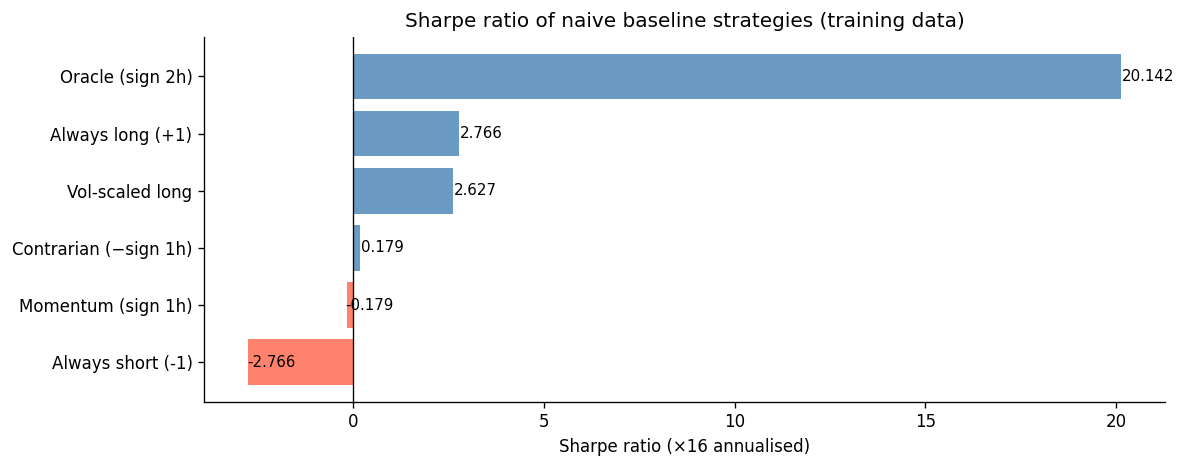

Always short (-1)        -2.766061
Momentum (sign 1h)       -0.178514
Contrarian (−sign 1h)     0.178514
Vol-scaled long           2.626637
Always long (+1)          2.766061
Oracle (sign 2h)         20.142286


In [44]:
def sharpe(positions, returns, scale=16):
    pnl = np.array(positions) * np.array(returns)
    return np.mean(pnl) / np.std(pnl) * scale if np.std(pnl) > 0 else 0.0

r2h = session_stats["return_2h"].values
r1h = session_stats["first_half_return"].values
vol = session_stats["bar_return_std"].values

strategies = {
    "Always long (+1)":      np.ones(1000),
    "Always short (-1)":     -np.ones(1000),
    "Momentum (sign 1h)":    np.sign(r1h),
    "Contrarian (−sign 1h)": -np.sign(r1h),
    "Vol-scaled long":        1 / (vol / vol.mean()),
    "Oracle (sign 2h)":      np.sign(r2h),   # upper bound
}

results = {name: sharpe(pos, r2h) for name, pos in strategies.items()}
sharpe_df = pd.Series(results).sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tomato" if v < 0 else "steelblue" for v in sharpe_df.values]
ax.barh(sharpe_df.index, sharpe_df.values, color=colors, alpha=0.8)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_title("Sharpe ratio of naive baseline strategies (training data)")
ax.set_xlabel("Sharpe ratio (×16 annualised)")
for i, (name, val) in enumerate(sharpe_df.items()):
    ax.text(val + 0.02 * np.sign(val), i, f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(sharpe_df.to_string())

## 13. Target Distribution & Outliers

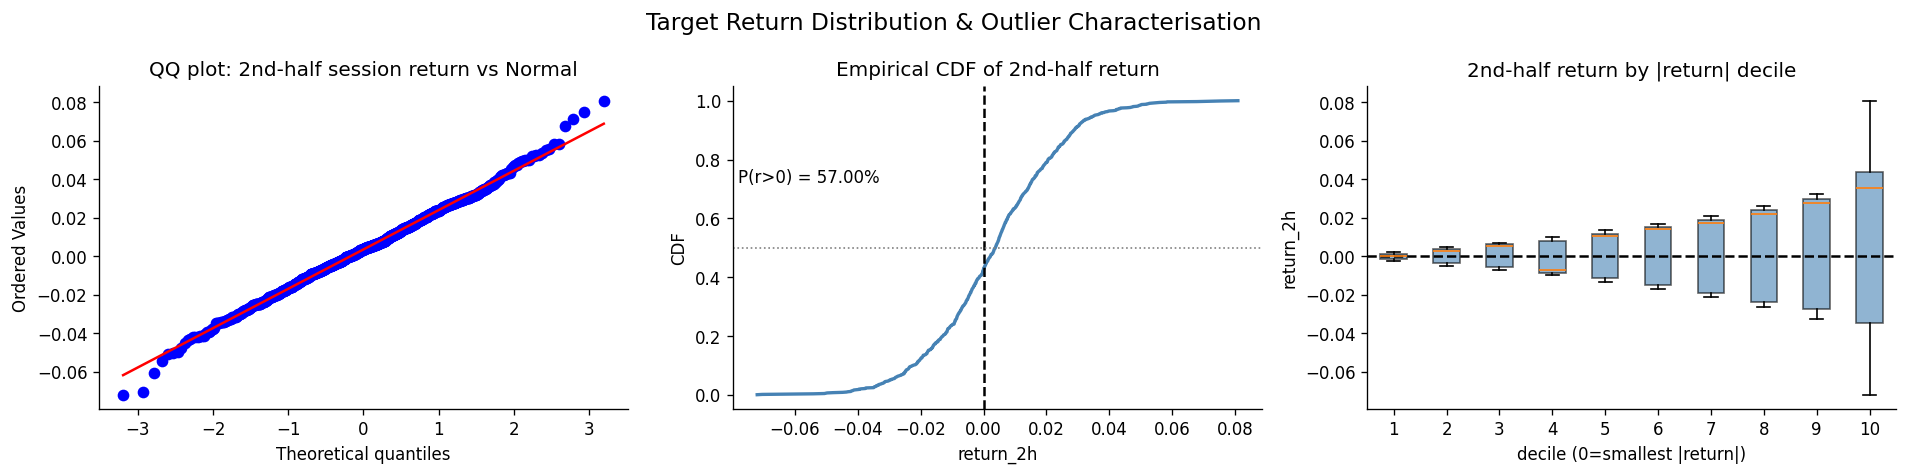

Skewness : 0.0295
Kurtosis : 0.4876
% within ±1%: 39.8%
% within ±2%: 66.7%


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. QQ plot of 2nd-half returns
from scipy.stats import probplot
probplot(session_stats["return_2h"], dist="norm", plot=axes[0])
axes[0].set_title("QQ plot: 2nd-half session return vs Normal")

# 2. Cumulative distribution
sorted_r = np.sort(session_stats["return_2h"])
cdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
axes[1].plot(sorted_r, cdf, color="steelblue", lw=2)
axes[1].axvline(0, color="k", linestyle="--")
axes[1].axhline(0.5, color="gray", linestyle=":", lw=1)
axes[1].set_title("Empirical CDF of 2nd-half return")
axes[1].set_xlabel("return_2h"); axes[1].set_ylabel("CDF")
pct_pos = (session_stats["return_2h"] > 0).mean()
axes[1].text(0.01, 0.7, f"P(r>0) = {pct_pos:.2%}", transform=axes[1].transAxes, fontsize=10)

# 3. Box plot by decile of return magnitude
session_stats["abs_return_decile"] = pd.qcut(session_stats["return_2h"].abs(), q=10, labels=False, duplicates="drop")
sess_by_dec = [session_stats.loc[session_stats["abs_return_decile"] == d, "return_2h"].values
               for d in sorted(session_stats["abs_return_decile"].dropna().unique())]
axes[2].boxplot(sess_by_dec, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[2].axhline(0, color="k", linestyle="--")
axes[2].set_title("2nd-half return by |return| decile")
axes[2].set_xlabel("decile (0=smallest |return|)"); axes[2].set_ylabel("return_2h")

plt.suptitle("Target Return Distribution & Outlier Characterisation", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Skewness : {session_stats['return_2h'].skew():.4f}")
print(f"Kurtosis : {session_stats['return_2h'].kurt():.4f}")
print(f"% within ±1%: {((session_stats['return_2h'].abs() < 0.01).mean()*100):.1f}%")
print(f"% within ±2%: {((session_stats['return_2h'].abs() < 0.02).mean()*100):.1f}%")

## 14. Key Findings & Modelling Implications

| Finding | Implication |
|---------|-------------|
| All sessions: exactly 50 seen / 50 unseen bars, prices normalised to 1.0 | No session length or scale effects to handle |
| 2nd-half return is ~N(0.35%, 2%) with slight positive drift | A simple long-only baseline has positive Sharpe |
| Bar returns are nearly serially uncorrelated (ACF ≈ 0), but |returns| show mild clustering | Price moves are close to a random walk; volatility regimes may be predictable |
| 1st-half momentum has **near-zero** correlation with 2nd-half return | Pure momentum is not a strong signal; check for subtle non-linear effects |
| 1st-half volatility is **moderately correlated** with 2nd-half |return| | Higher-vol sessions produce larger moves — useful for **position sizing** even if direction is hard |
| Close-in-range (price position within 1st-half H-L band) shows weak trend signal | May help as a mean-reversion / breakout feature |
| Keyword sentiment proxy has near-zero linear correlation with target | Headlines are noisy; may need LLM-based semantic scoring |
| Oracle Sharpe ≈ 2.7 (direction known) vs always-long Sharpe ≈ 0.27 | Direction prediction is the main lever; magnitude scaling adds a second layer |

### Suggested next steps
1. **Feature engineering**: rolling momentum, realised vol, spread trend, price position in range
2. **Non-linear models** (gradient boosting, small NN) on seen-half bar features
3. **LLM sentiment scoring** on headlines (company-specific tone, action verbs)
4. **Position sizing**: scale by predicted confidence / inverse volatility
5. **Cross-validation**: shuffle sessions; avoid look-ahead bias from the unseen data